# Communities and Crime — priprema podataka & EDA

**Skup podataka:** Communities and Crime Unnormalized (UCI Machine Learning Repository)  
**Izvor:** https://archive.ics.uci.edu/dataset/211/communities+and+crime+unnormalized  
**Instance:** 2215 | **Atributi:** 125 prediktivnih, 4 neprediktivna, 18 potencijalnih ciljnih  
**Zadatak:** Klasterovanje

---

Ova sveska pokriva:
1. Učitavanje sirovih podataka i dodela imena kolonama
2. Analiza nedostajućih vrednosti i vizuelizacija
3. Uklanjanje neinformativnih kolona i kolona sa previše nedostajućih vrednosti
4. Imputacija preostalih nedostajućih vrednosti medijanom
5. Normalizacija StandardScaler-om
6. Čuvanje pripremljenih podataka
7. EDA: raspodele atributa, toplotna mapa korelacija
8. PCA vizuelizacije u 2D i 3D

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Imena kolona

Sirova datoteka ne sadrži zaglavlje. Imena kolona su dodeljena prema zvaničnoj dokumentaciji UCI skupa podataka.  
Specijalni karakteri (`-`) u nazivima su zamenjeni sa `_` radi kompatibilnosti sa pandas bibliotekom.

In [41]:
# 147 columns: 5 identifiers + 124 predictive features + 18 crime targets
columns = [
    # --- Identifiers / metadata ---
    'communityname', 'State', 'countyCode', 'communityCode', 'fold',
    # --- Demographic features ---
    'pop', 'perHoush', 'pctBlack', 'pctWhite', 'pctAsian', 'pctHisp',
    'pct12_21', 'pct12_29', 'pct16_24', 'pct65up',
    'persUrban', 'pctUrban',
    # --- Income / economic ---
    'medIncome', 'pctWwage', 'pctWfarm', 'pctWdiv', 'pctWsocsec',
    'pctPubAsst', 'pctRetire',
    'medFamIncome', 'perCapInc', 'whitePerCap', 'blackPerCap',
    'NAperCap', 'asianPerCap', 'otherPerCap', 'hispPerCap',
    # --- Poverty / education ---
    'persPoverty', 'pctPoverty', 'pctLowEdu', 'pctNotHSgrad',
    'pctCollGrad', 'pctUnemploy', 'pctEmploy', 'pctEmployMfg',
    'pctEmployProfServ', 'pctOccupManu', 'pctOccupMgmt',
    # --- Family structure ---
    'pctMaleDivorc', 'pctMaleNevMar', 'pctFemDivorc', 'pctAllDivorc',
    'persPerFam', 'pct2Par', 'pctKids2Par', 'pctKids4w2Par',
    'pct12_17w2Par', 'pctWorkMom6', 'pctWorkMom18',
    'kidsBornNevrMarr', 'pctKidsBornNevrMarr',
    # --- Immigration ---
    'numForeignBorn', 'pctFgnImmig3', 'pctFgnImmig5',
    'pctFgnImmig8', 'pctFgnImmig10', 'pctImmig3', 'pctImmig5',
    'pctImmig8', 'pctImmig10', 'pctSpeakOnlyEng', 'pctNotSpeakEng',
    # --- Housing ---
    'pctLargHousFam', 'pctLargHous', 'persPerOccupHous',
    'persPerOwnOccup', 'persPerRenterOccup', 'pctPersOwnOccup',
    'pctPopDenseHous', 'pctSmallHousUnits', 'medNumBedrm',
    'houseVacant', 'pctHousOccup', 'pctHousOwnerOccup',
    'pctVacantBoarded', 'pctVacant6up', 'medYrHousBuilt',
    'pctHousWOphone', 'pctHousWOplumb',
    'ownHousLowQ', 'ownHousMed', 'ownHousUperQ', 'ownHousQrange',
    'rentLowQ', 'rentMed', 'rentUpperQ', 'rentQrange',
    'medGrossRent', 'medRentpctHousInc', 'medOwnCostpct', 'medOwnCostPctWO',
    # --- Homelessness ---
    'persEmergShelt', 'persHomeless',
    # --- Mobility ---
    'pctForeignBorn', 'pctBornStateResid',
    'pctSameHouse5', 'pctSameCounty5', 'pctSameState5',
    # --- Police ---
    'numPolice', 'policePerPop', 'policeField', 'policeFieldPerPop',
    'policeCalls', 'policCallPerPop', 'policCallPerOffic',
    'policePerPop2', 'racialMatch',
    'pctPolicWhite', 'pctPolicBlack', 'pctPolicHisp',
    'pctPolicAsian', 'pctPolicMinority',
    'officDrugUnits', 'numDiffDrugsSeiz', 'policAveOT',
    'landArea', 'popDensity', 'pctUsePubTrans',
    'policCarsAvail', 'policOperBudget', 'pctPolicPatrol',
    'gangUnit', 'pctOfficDrugUnit', 'policBudgetPerPop',
    # --- Crime targets (18) ---
    'murders', 'murdPerPop', 'rapes', 'rapesPerPop',
    'robberies', 'robbbPerPop', 'assaults', 'assaultPerPop',
    'burglaries', 'burglPerPop', 'larcenies', 'larcPerPop',
    'autoTheft', 'autoTheftPerPop', 'arsons', 'arsonsPerPop',
    'violentPerPop', 'nonViolPerPop'
]

print(f'Total columns defined: {len(columns)}')
assert len(columns) == 147, f'Expected 147, got {len(columns)}'

Total columns defined: 147


## 2. Učitavanje podataka

In [42]:
df = pd.read_csv(
    'CommViolPredUnnormalizedData.txt',
    header=None,
    names=columns,
    na_values='?'
)

print(f'Shape: {df.shape}')
print(f'\nColumn types:')
print(df.dtypes.value_counts())
df.head(3)

Shape: (2215, 147)

Column types:
float64    116
int64       29
str          2
Name: count, dtype: int64


,communityname,State,countyCode,communityCode,fold,pop,perHoush,pctBlack,pctWhite,pctAsian,...,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,violentPerPop,nonViolPerPop
0,BerkeleyHeightstownship,NJ,39.0,5320.0,1,11980,3.10,1.37,91.78,6.50,...,14.0,114.85,138.0,1132.08,16.0,131.26,2.0,16.41,41.02,1394.59
1,Marpletownship,PA,45.0,47616.0,1,23123,2.82,0.80,95.57,3.44,...,57.0,242.37,376.0,1598.78,26.0,110.55,1.0,4.25,127.56,1955.95
2,Tigardcity,OR,NaN,NaN,1,29344,2.43,0.74,94.33,3.43,...,274.0,758.14,1797.0,4972.19,136.0,376.30,22.0,60.87,218.59,6167.51


## 3. Analiza nedostajućih vrednosti i vizuelizacija

In [43]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Percentage', ascending=False)

print(f'Columns with missing values: {len(missing_df)} out of {len(df.columns)}')
print(f'\nTop 20 columns by missing percentage:')
missing_df.head(20)

Columns with missing values: 41 out of 147

Top 20 columns by missing percentage:


,Count,Percentage
policCarsAvail,1872,84.51
gangUnit,1872,84.51
policOperBudget,1872,84.51
policAveOT,1872,84.51
numDiffDrugsSeiz,1872,84.51
officDrugUnits,1872,84.51
pctPolicMinority,1872,84.51
pctPolicAsian,1872,84.51
pctPolicHisp,1872,84.51
pctPolicBlack,1872,84.51


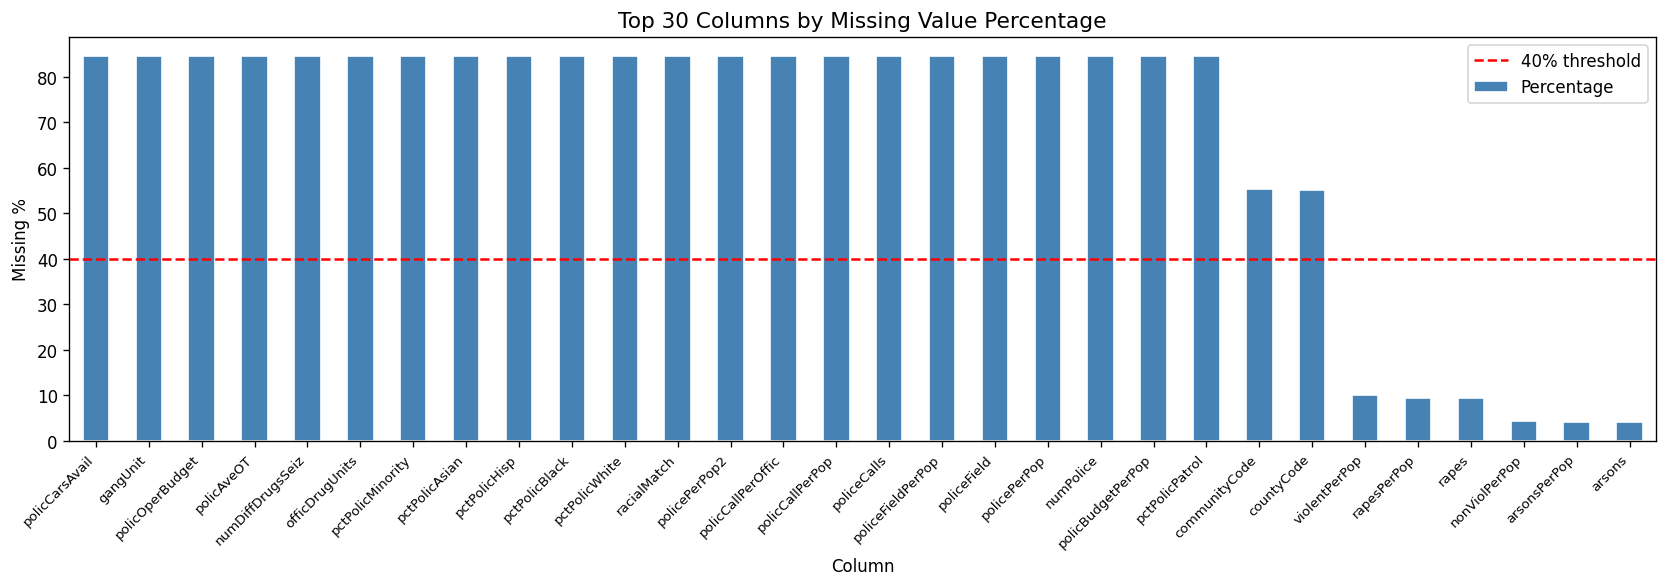

In [44]:
fig, ax = plt.subplots(figsize=(14, 5))
missing_df['Percentage'].head(30).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 30 Columns by Missing Value Percentage', fontsize=13)
ax.set_xlabel('Column')
ax.set_ylabel('Missing %')
ax.axhline(y=40, color='red', linestyle='--', linewidth=1.5, label='40% threshold')
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('figures/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Razdvajanje kolona

Kolone delimo u tri grupe:
- **Identifikatori** — ne koriste se za klasterovanje
- **Kolone karakteristika** — koriste se za klasterovanje nakon pripreme podataka
- **Ciljne kolone** — 18 ciljnih atributa; isključene iz klasterovanja, ali se koriste kasnije za interpretaciju klastera

In [45]:
id_cols = ['communityname', 'State', 'countyCode', 'communityCode', 'fold']

target_cols = [
    'murders', 'murdPerPop', 'rapes', 'rapesPerPop',
    'robberies', 'robbbPerPop', 'assaults', 'assaultPerPop',
    'burglaries', 'burglPerPop', 'larcenies', 'larcPerPop',
    'autoTheft', 'autoTheftPerPop', 'arsons', 'arsonsPerPop',
    'violentPerPop', 'nonViolPerPop'
]

feature_cols = [c for c in columns if c not in id_cols and c not in target_cols]
print(f'Identifier columns:  {len(id_cols)}')
print(f'Feature columns:     {len(feature_cols)}')
print(f'Target columns:      {len(target_cols)}')
print(f'Total:               {len(id_cols) + len(feature_cols) + len(target_cols)}')

Identifier columns:  5
Feature columns:     124
Target columns:      18
Total:               147


## 5. Uklanjanje kolona sa previše nedostajućih vrednosti

Kolone sa više od 40% nedostajućih vrednosti pružaju malo informacija i povećavaju grešku imputacije. Uklanjamo ih iz skupa atributa.

In [46]:
MISSING_THRESHOLD = 40

high_missing = missing_df[missing_df['Percentage'] > MISSING_THRESHOLD].index.tolist()
high_missing_features = [c for c in high_missing if c in feature_cols]

print(f'Feature columns dropped (>{MISSING_THRESHOLD}% missing): {len(high_missing_features)}')
for col in high_missing_features:
    pct = missing_df.loc[col, 'Percentage']
    print(f'  {col}: {pct}% missing')

feature_cols_clean = [c for c in feature_cols if c not in high_missing_features]
print(f'\nRemaining feature columns: {len(feature_cols_clean)}')

Feature columns dropped (>40% missing): 22
  policCarsAvail: 84.51% missing
  gangUnit: 84.51% missing
  policOperBudget: 84.51% missing
  policAveOT: 84.51% missing
  numDiffDrugsSeiz: 84.51% missing
  officDrugUnits: 84.51% missing
  pctPolicMinority: 84.51% missing
  pctPolicAsian: 84.51% missing
  pctPolicHisp: 84.51% missing
  pctPolicBlack: 84.51% missing
  pctPolicWhite: 84.51% missing
  racialMatch: 84.51% missing
  policePerPop2: 84.51% missing
  policCallPerOffic: 84.51% missing
  policCallPerPop: 84.51% missing
  policeCalls: 84.51% missing
  policeFieldPerPop: 84.51% missing
  policeField: 84.51% missing
  policePerPop: 84.51% missing
  numPolice: 84.51% missing
  policBudgetPerPop: 84.51% missing
  pctPolicPatrol: 84.51% missing

Remaining feature columns: 102


## 6. Imputacija, normalizacija i čuvanje pripremljenih podataka

In [47]:
X_raw = df[feature_cols_clean].copy()
y = df[target_cols].copy().reset_index(drop=True)

print(f'Feature matrix shape: {X_raw.shape}')
print(f'Remaining missing values: {X_raw.isnull().sum().sum()}')

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_raw),
    columns=feature_cols_clean
)
print(f'After imputation — missing: {X_imputed.isnull().sum().sum()}')

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_imputed),
    columns=feature_cols_clean
)
print(f'Scaling complete. Mean ≈ {X_scaled.mean().mean():.4f}, Std ≈ {X_scaled.std().mean():.4f}')

X_scaled.to_csv('data_preprocessed.csv', index=False)
X_imputed.to_csv('data_imputed.csv', index=False)
y.to_csv('data_targets.csv', index=False)

print('\nSaved:')
print('  data_preprocessed.csv  — scaled features for clustering')
print('  data_imputed.csv       — imputed unscaled features')
print('  data_targets.csv       — 18 crime target variables')

Feature matrix shape: (2215, 102)
Remaining missing values: 1
After imputation — missing: 0
Scaling complete. Mean ≈ 0.0000, Std ≈ 1.0002

Saved:
  data_preprocessed.csv  — scaled features for clustering
  data_imputed.csv       — imputed unscaled features
  data_targets.csv       — 18 crime target variables


## 7. Provera anomalija i autlajera

Proveravamo prisustvo anomalija na tri načina:
1. **Z-skor** — vrednosti koje su na više od 3 standardne devijacije od srednje vrednosti
2. **Logičke granice** — procentualni atributi ne smeju biti van opsega [0, 100]
3. **Box plot** — vizuelni prikaz autlajera za ključne atribute

Columns with outliers (|z| > 3): 98
Total outlier values flagged:    2869

Top 10 columns by outlier count:
pctHisp             67
pctSpeakOnlyEng     62
pctNotSpeakEng      60
pctOfficDrugUnit    57
pctBlack            57
ownHousUperQ        55
pct16_24            55
pctUsePubTrans      54
pctPopDenseHous     54
pctImmig8           53

No logical range violations found in percentage columns.


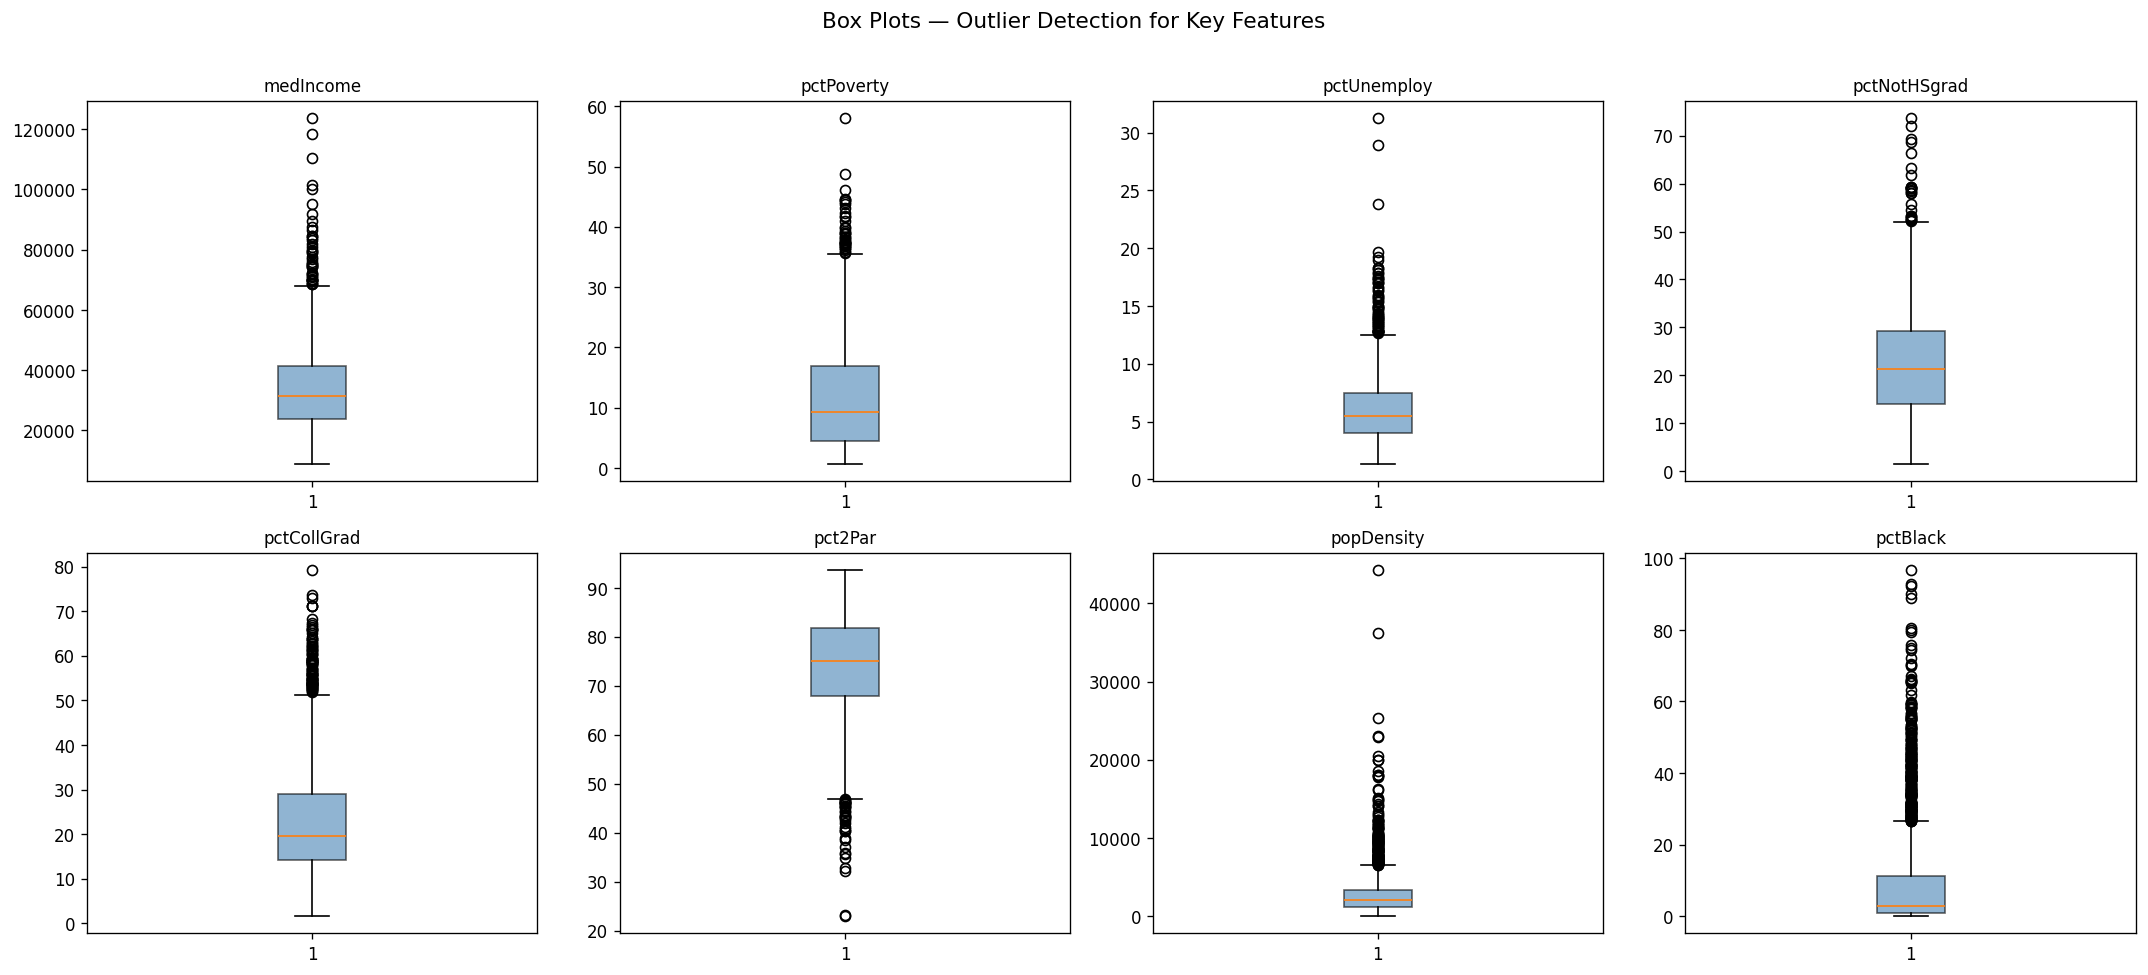


Note: Outliers are retained — they represent real communities (e.g. large cities)
and removing them would distort the natural structure of the data.


In [48]:
from scipy import stats

z_scores = pd.DataFrame(np.abs(stats.zscore(X_imputed)), columns=X_imputed.columns)
outlier_counts = (z_scores > 3).sum()
outlier_cols = outlier_counts[outlier_counts > 0].sort_values(ascending=False)

print(f'Columns with outliers (|z| > 3): {len(outlier_cols)}')
print(f'Total outlier values flagged:    {outlier_counts.sum()}')
print(f'\nTop 10 columns by outlier count:')
print(outlier_cols.head(10).to_string())

pct_cols = [c for c in X_imputed.columns if c.startswith('pct')]
violations = {}
for col in pct_cols:
    out_of_range = ((X_imputed[col] < 0) | (X_imputed[col] > 100)).sum()
    if out_of_range > 0:
        violations[col] = out_of_range

if violations:
    print(f'\nPercentage columns with values outside [0, 100]:')
    for col, count in violations.items():
        print(f'  {col}: {count} violations')
else:
    print(f'\nNo logical range violations found in percentage columns.')

key_features = ['medIncome', 'pctPoverty', 'pctUnemploy', 'pctNotHSgrad',
                 'pctCollGrad', 'pct2Par', 'popDensity', 'pctBlack']
key_available = [c for c in key_features if c in X_imputed.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(key_available):
    axes[i].boxplot(X_imputed[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Box Plots — Outlier Detection for Key Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nNote: Outliers are retained — they represent real communities (e.g. large cities)')
print('and removing them would distort the natural structure of the data.')

## 8. Raspodele karakteristika

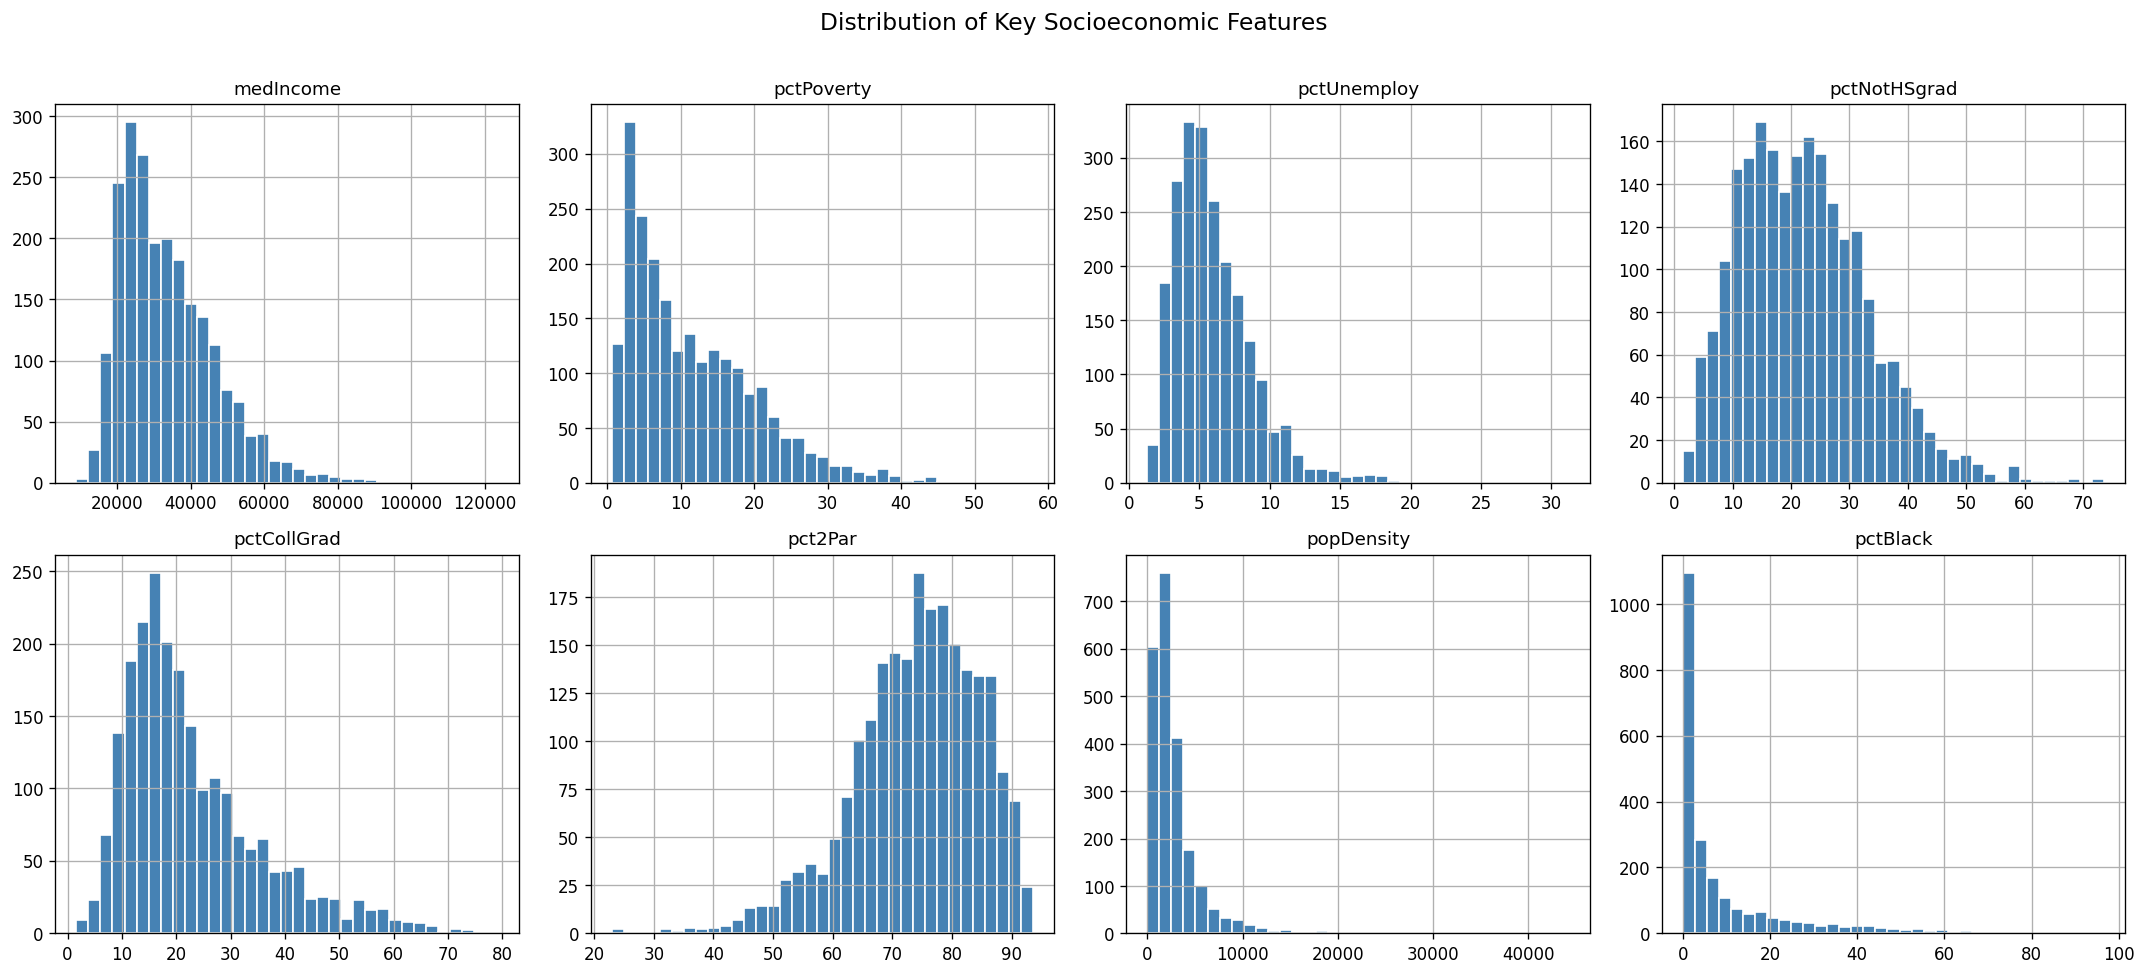

In [49]:
key_features = [
    'medIncome', 'pctPoverty', 'pctUnemploy', 'pctNotHSgrad',
    'pctCollGrad', 'pct2Par', 'popDensity', 'pctBlack'
]
key_available = [c for c in key_features if c in X_imputed.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(key_available):
    X_imputed[col].hist(ax=axes[i], bins=35, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribution of Key Socioeconomic Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figures/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

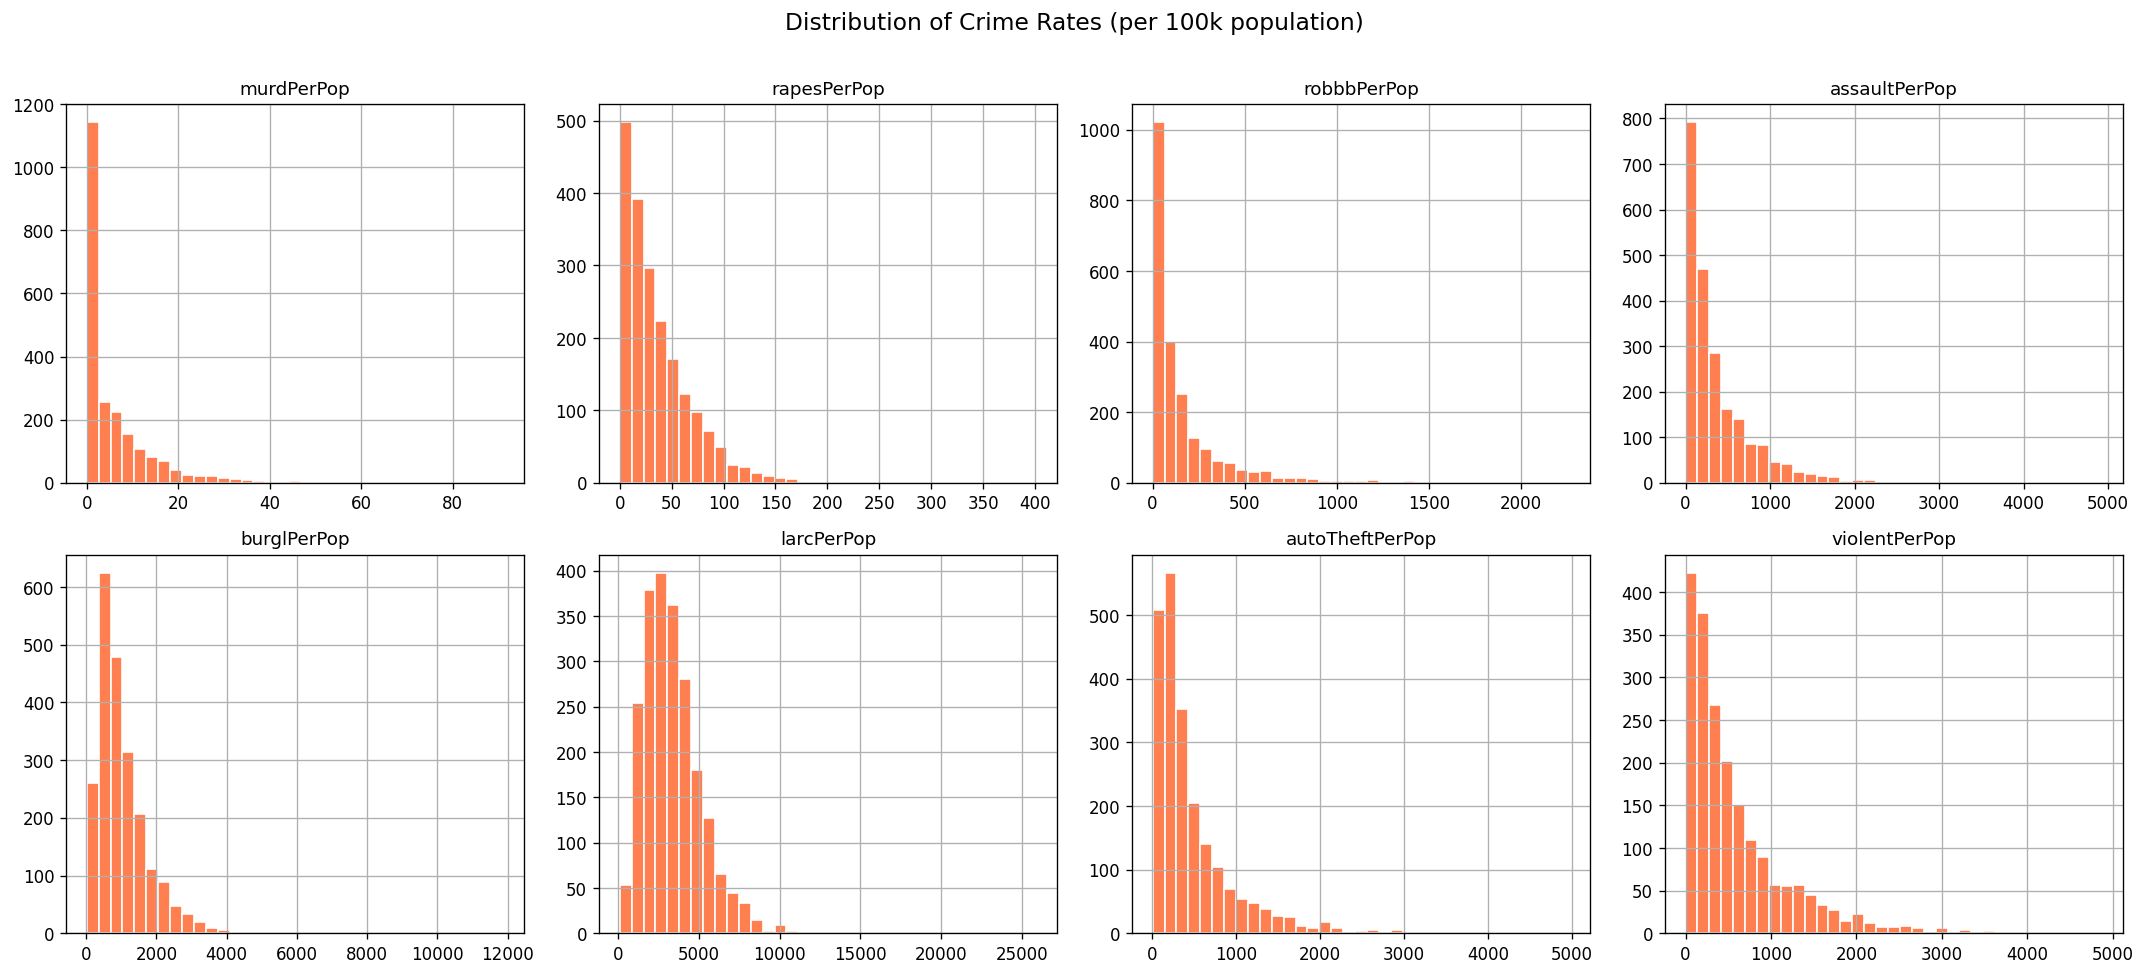

In [50]:
crime_per_pop = [
    'murdPerPop', 'rapesPerPop', 'robbbPerPop', 'assaultPerPop',
    'burglPerPop', 'larcPerPop', 'autoTheftPerPop', 'violentPerPop'
]
crime_available = [c for c in crime_per_pop if c in y.columns and y[c].notna().sum() > 100]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(crime_available[:8]):
    y[col].dropna().hist(ax=axes[i], bins=35, color='coral', edgecolor='white')
    axes[i].set_title(col, fontsize=11)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribution of Crime Rates (per 100k population)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figures/crime_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Toplotne mape korelacija

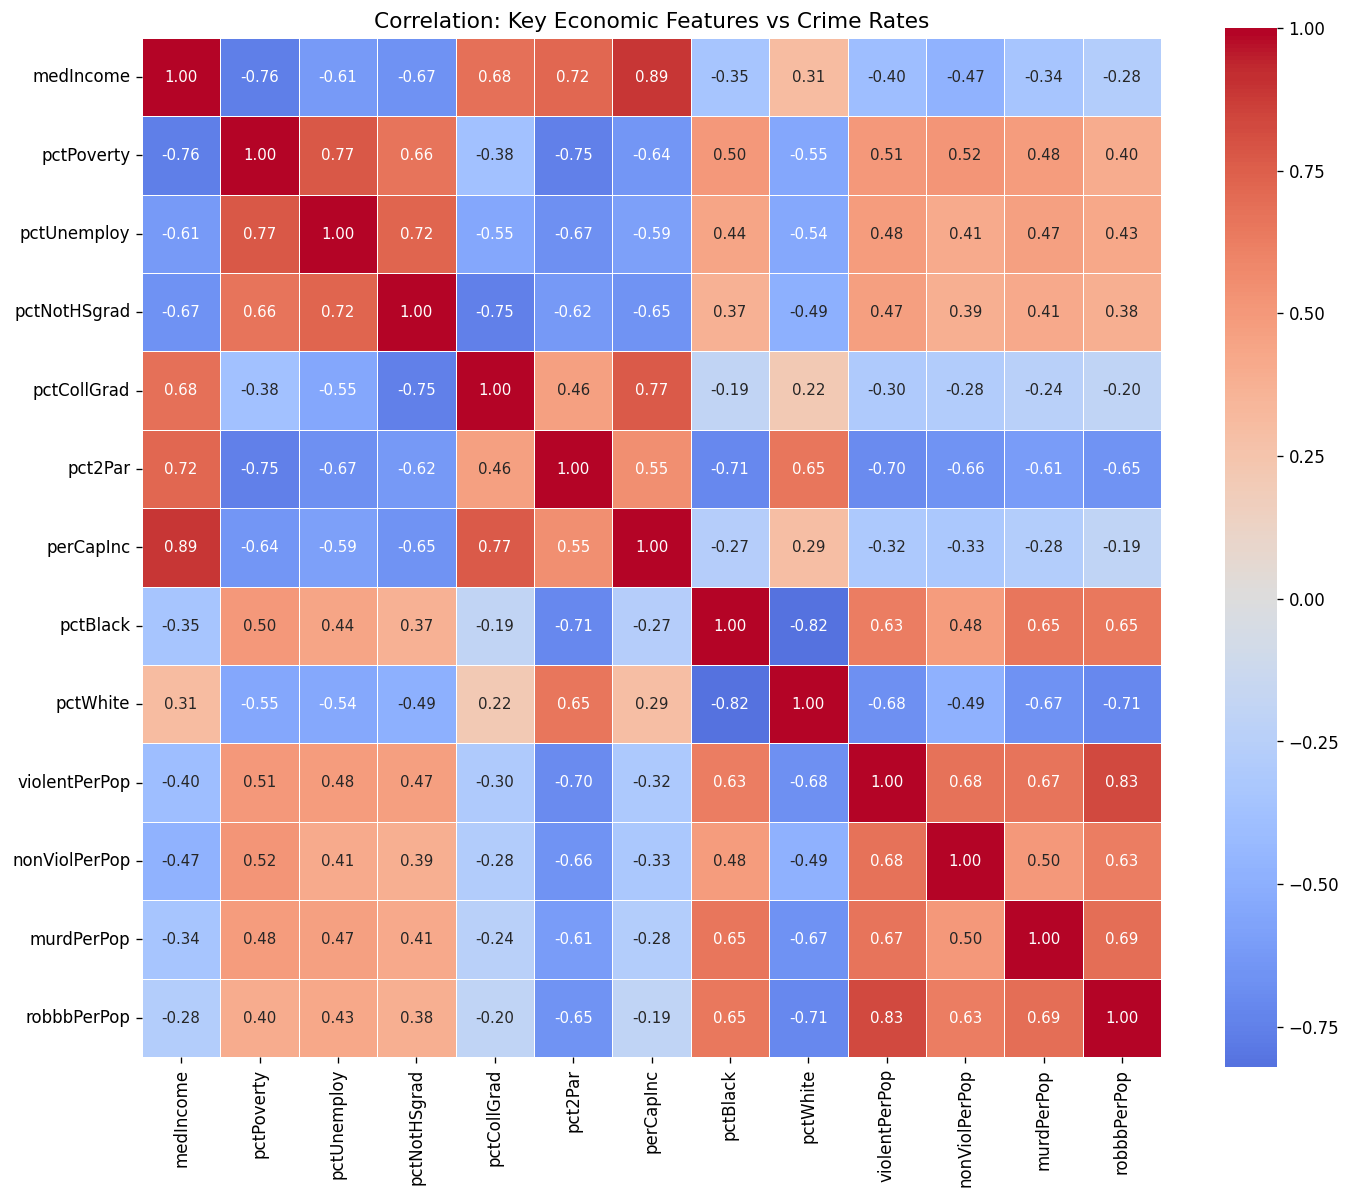

In [51]:
econ_features = [
    'medIncome', 'pctPoverty', 'pctUnemploy', 'pctNotHSgrad',
    'pctCollGrad', 'pct2Par', 'perCapInc', 'pctBlack', 'pctWhite'
]
econ_avail = [c for c in econ_features if c in X_imputed.columns]
crime_subset = ['violentPerPop', 'nonViolPerPop', 'murdPerPop', 'robbbPerPop']
crime_avail = [c for c in crime_subset if c in y.columns]

corr_df = pd.concat([X_imputed[econ_avail], y[crime_avail]], axis=1)
corr_matrix = corr_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5, annot_kws={'size': 9}
)
plt.title('Correlation: Key Economic Features vs Crime Rates', fontsize=13)
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. PCA — Objašnjena varijansa i redukovani skupovi podataka

Components for 70% explained variance: 7
Components for 80% explained variance: 12


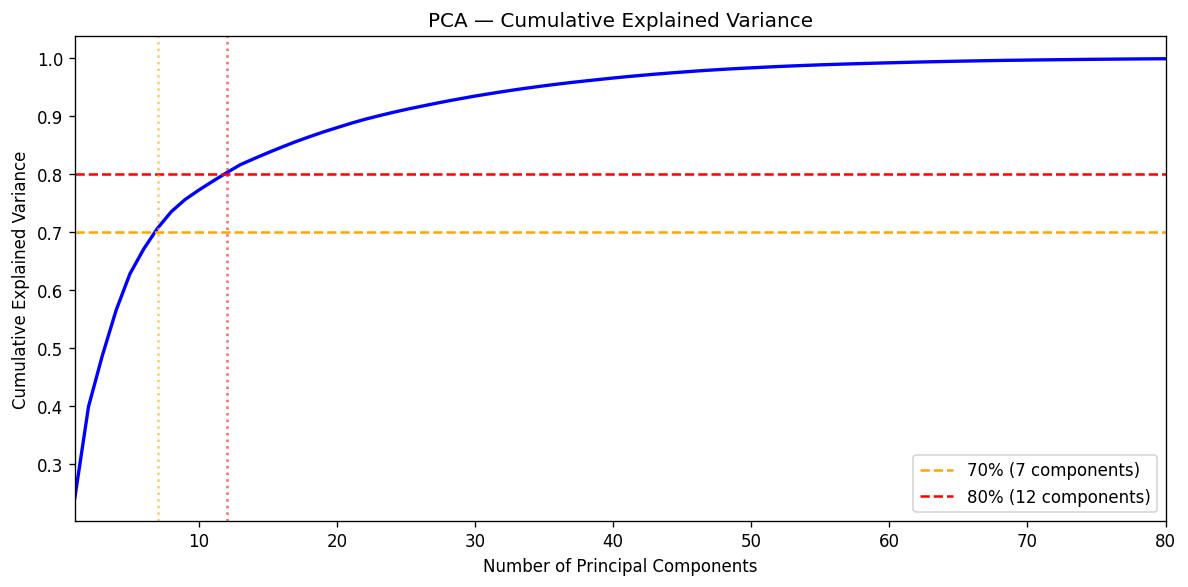

Saved data_pca_70.csv (7 components)
Saved data_pca_80.csv (12 components)


In [52]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

n_70 = int(np.argmax(cumvar >= 0.70)) + 1
n_80 = int(np.argmax(cumvar >= 0.80)) + 1
print(f'Components for 70% explained variance: {n_70}')
print(f'Components for 80% explained variance: {n_80}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar) + 1), cumvar, 'b-', linewidth=2)
ax.axhline(y=0.70, color='orange', linestyle='--', label=f'70% ({n_70} components)')
ax.axhline(y=0.80, color='red', linestyle='--', label=f'80% ({n_80} components)')
ax.axvline(x=n_70, color='orange', linestyle=':', alpha=0.6)
ax.axvline(x=n_80, color='red', linestyle=':', alpha=0.6)
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA — Cumulative Explained Variance')
ax.legend()
ax.set_xlim(1, 80)
plt.tight_layout()
plt.savefig('figures/pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

for n_comp, label in [(n_70, 'pca_70'), (n_80, 'pca_80')]:
    pca_n = PCA(n_components=n_comp, random_state=42)
    X_pca = pca_n.fit_transform(X_scaled)
    pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_comp)]).to_csv(
        f'data_{label}.csv', index=False
    )
    print(f'Saved data_{label}.csv ({n_comp} components)')

## 11. Podskup ekonomskih karakteristika

Pored PCA redukcije, kreiramo i podskup od 20 karakteristika odabranih na osnovu domenskog znanja — 
atributi koji su u literaturi iz kriminologije najdirektnije povezani sa kriminalom 
(prihodi, siromaštvo, nezaposlenost, obrazovanje, struktura porodice, urbanizacija).

Ovaj podskup omogućava **interpretabilno klasterovanje** i direktno poređenje sa:
- klasterovanjem nad svih 102 karakteristika
- klasterovanjem nad PCA komponentama (matematička redukcija dimenzionalnosti)

In [53]:
economic_features = [
    'medIncome', 'pctPoverty', 'pctUnemploy', 'pctNotHSgrad', 'pctCollGrad',
    'pct2Par', 'perCapInc', 'pctBlack', 'pctWhite', 'pctHisp',
    'medFamIncome', 'pctPubAsst', 'pctWsocsec', 'pctRetire',
    'pctMaleDivorc', 'pctFemDivorc', 'pctKids2Par',
    'pop', 'popDensity', 'pctUrban'
]
econ_cols = [c for c in economic_features if c in feature_cols_clean]
X_econ = X_scaled[econ_cols].copy()
X_econ.to_csv('data_economic.csv', index=False)
print(f'Economic subset saved: {len(econ_cols)} features')
print(econ_cols)

Economic subset saved: 20 features
['medIncome', 'pctPoverty', 'pctUnemploy', 'pctNotHSgrad', 'pctCollGrad', 'pct2Par', 'perCapInc', 'pctBlack', 'pctWhite', 'pctHisp', 'medFamIncome', 'pctPubAsst', 'pctWsocsec', 'pctRetire', 'pctMaleDivorc', 'pctFemDivorc', 'pctKids2Par', 'pop', 'popDensity', 'pctUrban']


## 12. PCA - 2D vizuelizacija

Explained variance (2 components): 39.97%


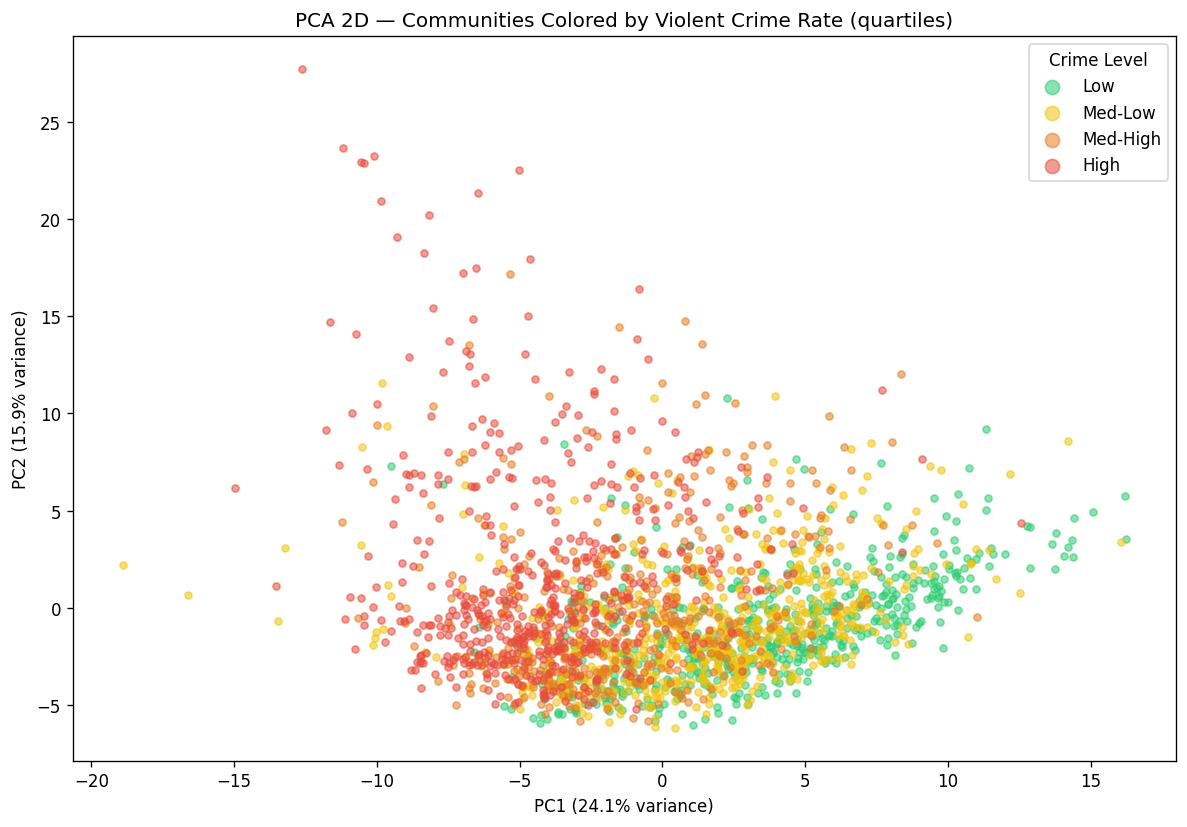

In [54]:
pca2d = PCA(n_components=2, random_state=42)
X_pca2d = pca2d.fit_transform(X_scaled)
print(f'Explained variance (2 components): {pca2d.explained_variance_ratio_.sum():.2%}')

# Color by violent crime rate quartiles
violent = y['violentPerPop'].fillna(y['violentPerPop'].median())
quartiles = pd.qcut(violent, q=4, labels=['Low', 'Med-Low', 'Med-High', 'High'])
color_map = {'Low': '#2ecc71', 'Med-Low': '#f1c40f', 'Med-High': '#e67e22', 'High': '#e74c3c'}

fig, ax = plt.subplots(figsize=(10, 7))
for label in ['Low', 'Med-Low', 'Med-High', 'High']:
    mask = quartiles == label
    ax.scatter(
        X_pca2d[mask, 0], X_pca2d[mask, 1],
        c=color_map[label], label=label, alpha=0.55, s=18
    )
ax.set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA 2D — Communities Colored by Violent Crime Rate (quartiles)')
ax.legend(title='Crime Level', markerscale=2)
plt.tight_layout()
plt.savefig('figures/pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. PCA - 3D vizuelizacija

Explained variance (3 components): 48.75%


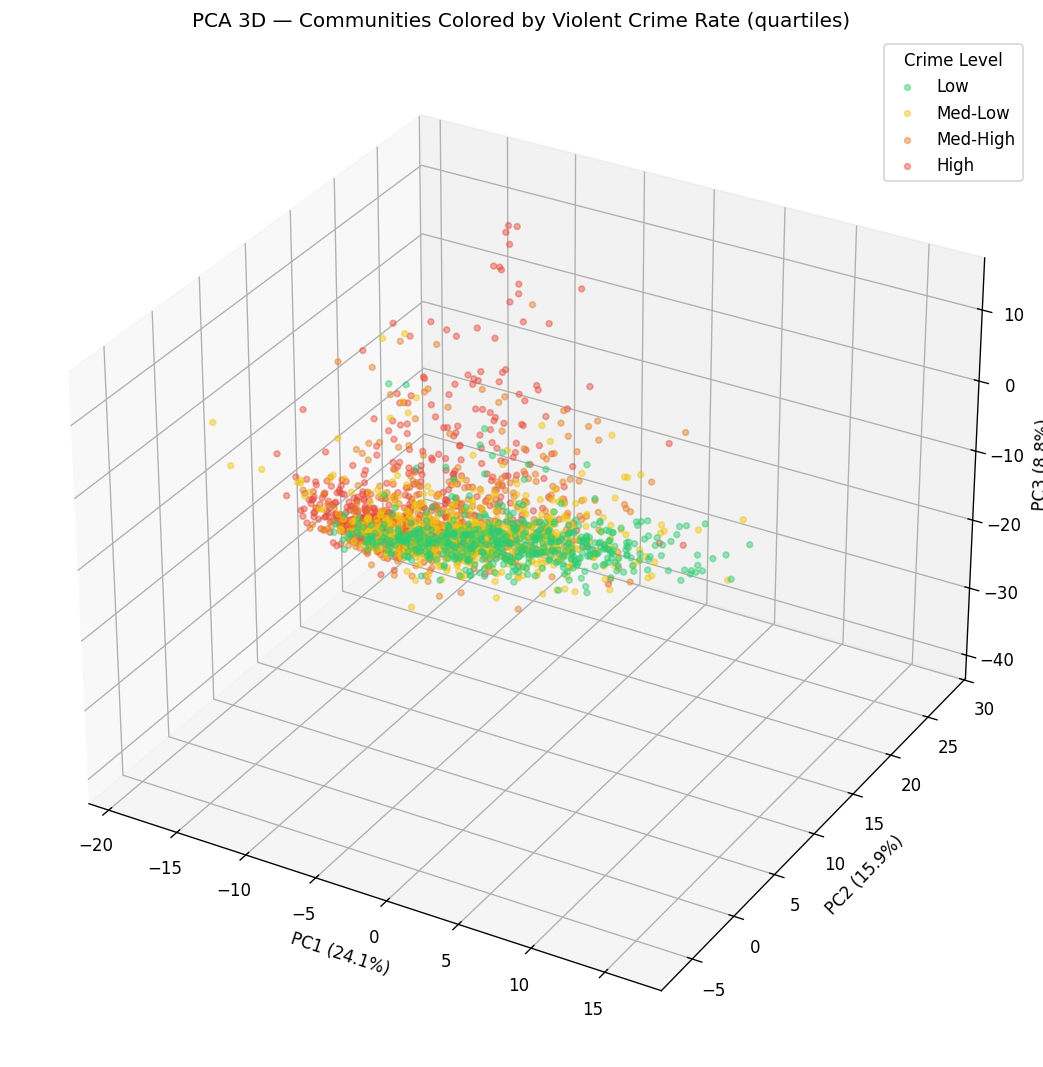

In [55]:
pca3d = PCA(n_components=3, random_state=42)
X_pca3d = pca3d.fit_transform(X_scaled)
print(f'Explained variance (3 components): {pca3d.explained_variance_ratio_.sum():.2%}')

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
for label in ['Low', 'Med-Low', 'Med-High', 'High']:
    mask = (quartiles == label).values
    ax.scatter(
        X_pca3d[mask, 0], X_pca3d[mask, 1], X_pca3d[mask, 2],
        c=color_map[label], label=label, alpha=0.45, s=12
    )
ax.set_xlabel(f'PC1 ({pca3d.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca3d.explained_variance_ratio_[1]:.1%})')
ax.set_zlabel(f'PC3 ({pca3d.explained_variance_ratio_[2]:.1%})')
ax.set_title('PCA 3D — Communities Colored by Violent Crime Rate (quartiles)')
ax.legend(title='Crime Level')
plt.tight_layout()
plt.savefig('figures/pca_3d.png', dpi=150, bbox_inches='tight')
plt.show()

## Rezime

In [56]:
n_70 = pd.read_csv('data_pca_70.csv').shape[1]
n_80 = pd.read_csv('data_pca_80.csv').shape[1]
print('=== PREPROCESSING SUMMARY ===')
print(f'Original dataset:          2215 rows x 147 columns')
print(f'Feature columns after clean: {len(feature_cols_clean)}')
print(f'Columns dropped (high NaN):  {len(high_missing_features)}')
print(f'Missing values after impute: 0')
print(f'Scaling:                     StandardScaler')
print()
print('Saved datasets:')
print(f'  data_preprocessed.csv  — {len(feature_cols_clean)} scaled features')
print(f'  data_pca_70.csv         — {n_70} PCA components (70% variance)')
print(f'  data_pca_80.csv         — {n_80} PCA components (80% variance)')
print(f'  data_economic.csv       — {len(econ_cols)} economic features (scaled)')
print(f'  data_targets.csv        — 18 crime targets (for cluster interpretation)')
print(f'  data_imputed.csv        — imputed unscaled features')

=== PREPROCESSING SUMMARY ===
Original dataset:          2215 rows x 147 columns
Feature columns after clean: 102
Columns dropped (high NaN):  22
Missing values after impute: 0
Scaling:                     StandardScaler

Saved datasets:
  data_preprocessed.csv  — 102 scaled features
  data_pca_70.csv         — 7 PCA components (70% variance)
  data_pca_80.csv         — 12 PCA components (80% variance)
  data_economic.csv       — 20 economic features (scaled)
  data_targets.csv        — 18 crime targets (for cluster interpretation)
  data_imputed.csv        — imputed unscaled features
